In [408]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [409]:
df = pd.read_csv("train.csv")

In [410]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [411]:

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Ticket', 'PassengerId','Cabin'])

In [412]:

df['Age'] = df['Age'].astype(int)
df['Survived'] = df['Survived'].astype(bool)
df['Pclass'] = df['Pclass'].astype('category')

In [413]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex']      = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df['Survived']    = le.fit_transform(df['Survived'])
df['Name']   = le.fit_transform(df['Name'])

print(df.head())

   Survived Pclass  Name  Sex  Age  SibSp  Parch     Fare  Embarked
0         0      3   108    1   22      1      0   7.2500         2
1         1      1   190    0   38      1      0  71.2833         0
2         1      3   353    0   26      0      0   7.9250         2
3         1      1   272    0   35      1      0  53.1000         2
4         0      3    15    1   35      0      0   8.0500         2


In [414]:
X = df[['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']


In [415]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)


In [416]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

In [417]:
print(X_scaled.shape)
print(X_train.shape)
print(X_test.shape)


(891, 8)
(712, 8)
(179, 8)


In [418]:
model = LogisticRegression()

In [419]:
model.fit(X_train, y_train)

LogisticRegression()

In [420]:
y_train_pred = model.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))

Training Accuracy: 0.8033707865168539


In [421]:
y_test_pred = model.predict(X_test)
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))

Testing Accuracy: 0.8156424581005587


In [422]:
df2 = pd.read_csv("test.csv")

In [423]:
df2.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [424]:

df2['Age'] = df2['Age'].fillna(df2['Age'].mean())
df2['Fare'] = df2['Fare'].fillna(df2['Fare'].mean())
df2 = df2.drop(columns=['Ticket', 'PassengerId','Cabin'])

In [425]:

df2['Age'] = df2['Age'].astype(int)
df2['Pclass'] = df2['Pclass'].astype('category')

In [426]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df2['Sex']      = le.fit_transform(df2['Sex'])
df2['Embarked'] = le.fit_transform(df2['Embarked'])

df2['Name']   = le.fit_transform(df2['Name'])

print(df2.head())

  Pclass  Name  Sex  Age  SibSp  Parch     Fare  Embarked
0      3   206    1   34      0      0   7.8292         1
1      3   403    0   47      1      0   7.0000         2
2      2   269    1   62      0      0   9.6875         1
3      3   408    1   27      0      0   8.6625         2
4      3   178    0   22      1      1  12.2875         2


In [427]:
print("Test shape :", df2.shape)

Test shape : (418, 8)


In [428]:

print("X_train columns:", X.columns.tolist())
print("df2 columns    :", df2.columns.tolist())

X_train columns: ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df2 columns    : ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [429]:
X_new = sc.transform(df2)

In [430]:
# ─────────────────────────────────────
# Predict for the whole test dataset
# ─────────────────────────────────────

# Predict for test.csv passengers
X_new        = sc.transform(df2)
predictions  = model.predict(X_new)
probabilities = model.predict_proba(X_new)

# Show prediction for first passenger
print("Prediction (0=Not Survived, 1=Survived):", predictions[0])
print("Probability [Not Survived, Survived]    :", probabilities[0])

# ─────────────────────────────────────
# Show all predictions
# ─────────────────────────────────────
results = pd.read_csv("test.csv")[['PassengerId']]
results['Survived']           = predictions
results['Result']             = results['Survived'].map({
    1: '✅ Survived',
    0: '❌ Not Survived'
})
results['Prob_Not_Survived']  = probabilities[:, 0].round(2)
results['Prob_Survived']      = probabilities[:, 1].round(2)

print("\n── Predictions for test.csv ──")
print(results.head(20))

print("\n── Summary ──")
print(f"Total Passengers : {len(results)}")
print(f"✅ Survived       : {results['Survived'].sum()}")
print(f"❌ Not Survived   : {(results['Survived'] == 0).sum()}")

# Save to CSV
results.to_csv("predictions.csv", index=False)
print("\n✅ Saved to predictions.csv")

Prediction (0=Not Survived, 1=Survived): 0
Probability [Not Survived, Survived]    : [0.87532636 0.12467364]

── Predictions for test.csv ──
    PassengerId  Survived          Result  Prob_Not_Survived  Prob_Survived
0           892         0  ❌ Not Survived               0.88           0.12
1           893         0  ❌ Not Survived               0.57           0.43
2           894         0  ❌ Not Survived               0.87           0.13
3           895         0  ❌ Not Survived               0.89           0.11
4           896         1      ✅ Survived               0.38           0.62
5           897         0  ❌ Not Survived               0.84           0.16
6           898         1      ✅ Survived               0.28           0.72
7           899         0  ❌ Not Survived               0.79           0.21
8           900         1      ✅ Survived               0.17           0.83
9           901         0  ❌ Not Survived               0.91           0.09
10          902        

In [431]:
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

[[90 15]
 [18 56]]


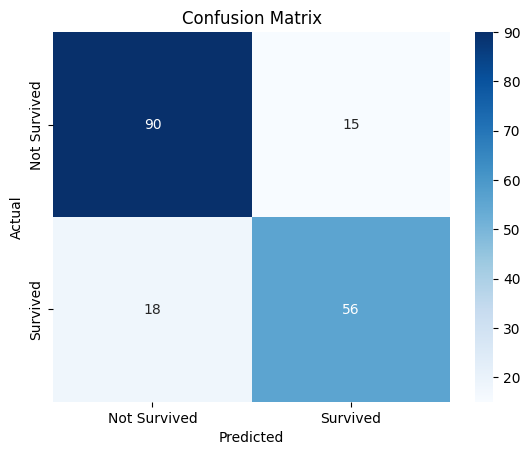

In [432]:

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [433]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



In [434]:
# Create polynomial features from the scaled data
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)

In [435]:
print("Original features:", X_scaled.shape[1])
print("Polynomial features:", X_poly.shape[1])

Original features: 8
Polynomial features: 45


In [436]:


X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.20, random_state=42)

In [437]:
model_poly = LogisticRegression(max_iter=1000)
model_poly.fit(X_train_poly, y_train_poly)

LogisticRegression(max_iter=1000)

In [438]:
y_train_poly_pred = model_poly.predict(X_train_poly)
y_test_poly_pred  = model_poly.predict(X_test_poly)
print("Training Accuracy (Polynomial):", accuracy_score(y_train_poly, y_train_poly_pred))
print("Testing Accuracy  (Polynomial):", accuracy_score(y_test_poly,  y_test_poly_pred))

Training Accuracy (Polynomial): 0.848314606741573
Testing Accuracy  (Polynomial): 0.8100558659217877


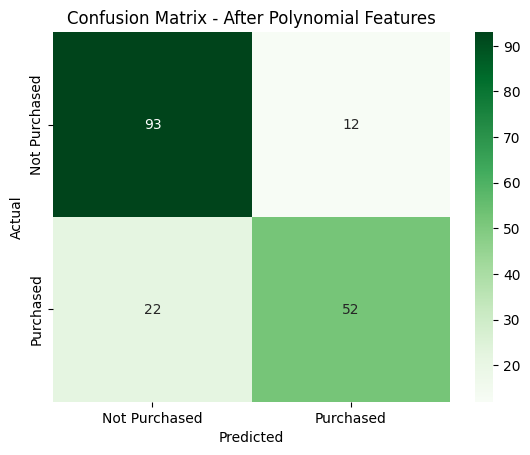

In [439]:
# Confusion matrix after polynomial improvement
cm_poly = confusion_matrix(y_test_poly, y_test_poly_pred)
sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - After Polynomial Features')
plt.show()

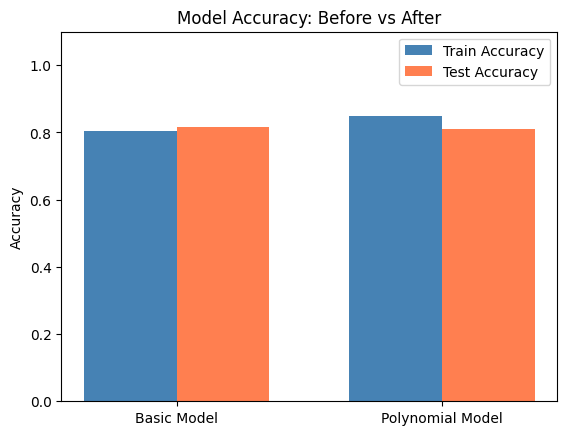

In [440]:
# Bar chart comparing accuracy before and after improvement
models    = ['Basic Model', 'Polynomial Model']
train_scores = [
    accuracy_score(y_train, y_train_pred),
    accuracy_score(y_train_poly, y_train_poly_pred)
]
test_scores = [
    accuracy_score(y_test, y_test_pred),
    accuracy_score(y_test_poly, y_test_poly_pred)
]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, train_scores, width, label='Train Accuracy', color='steelblue')
ax.bar(x + width/2, test_scores,  width, label='Test Accuracy',  color='coral')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy: Before vs After')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend()
plt.show()